**Introduction to Scikit-learn**

 *O que é?*

 - E uma biblioteca de python para aprendizado de máquina
 - Ela é capaz de trabalhar com vários modelos preditivos

*Machine learn*

É a forma de realizar previsões e predições a partir dos dados já analizados


*Exemplos de modelos lineares*

y = ax + b

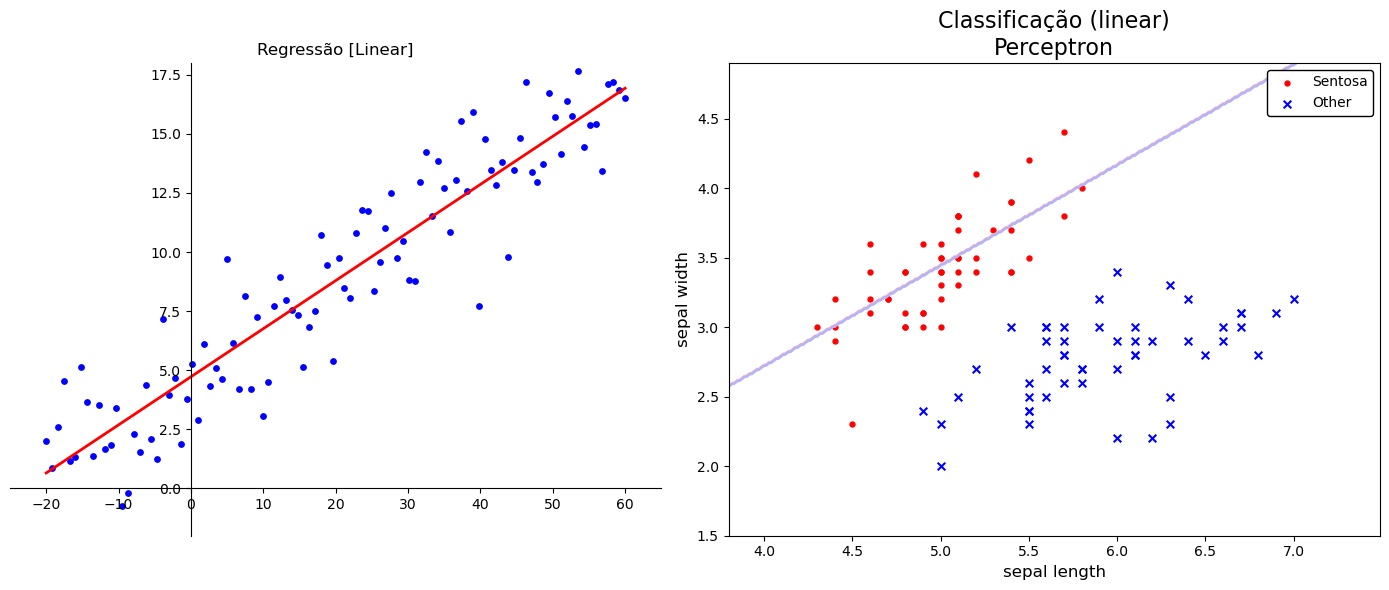

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression, Perceptron

fig, axs = plt.subplots(1,2, figsize=(14, 6));
np.random.seed(42);
Xreg = np.linspace(-20, 60, 100).reshape(-1,1);
Yreg = 0.2 * Xreg.ravel() + 5  + np.random.randn(100)*2;

regressor = LinearRegression();
regressor.fit(Xreg,Yreg);
pred = regressor.predict(Xreg);
axs[0].scatter(Xreg,Yreg, color='Blue', s=15, label='Data points');
axs[0].plot(Xreg, pred, color='red', linewidth=2, label='y = ax + b');

axs[0].set_title('Regressão [Linear]');
axs[0].spines['left'].set_position('zero')
axs[0].spines['bottom'].set_position('zero')
axs[0].spines['right'].set_color('none')
axs[0].spines['top'].set_color('none')
axs[0].set_xlim(-25,65)
axs[0].set_ylim(-2, 18)

iris = load_iris()

x_cls = iris.data[:100, :2]
y_cls = iris.target[:100]

classifier = Perceptron(max_iter=1000, random_state=42);
classifier.fit(x_cls, y_cls)

xmin, xmax = x_cls[:, 0].min() - 0.5, x_cls[:, 0].max() + 0.5
ymin, ymax = x_cls[:, 1].min() - 0.5, x_cls[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(xmin, xmax, 0.01), np.arange(ymin, ymax, 0.01))

z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)

cmap_light = ListedColormap(['#ffb3b3', '#b3b3ff'])

axs[1].contour(xx, yy, z, cmap=cmap_light, alpha=0.8);

axs[1].scatter(x_cls[y_cls == 0, 0], x_cls[y_cls == 0, 1], color='red', marker='.', s=50, label='Sentosa');
axs[1].scatter(x_cls[y_cls == 1, 0], x_cls[y_cls == 1, 1], color='blue', marker='x', s=30, label='Other');

axs[1].set_title('Classificação (linear)\nPerceptron', fontsize=16)
axs[1].set_xlabel('sepal length', fontsize=12)
axs[1].set_ylabel('sepal width', fontsize=12)
axs[1].legend(loc='upper right', framealpha=1, edgecolor='black')

plt.tight_layout()

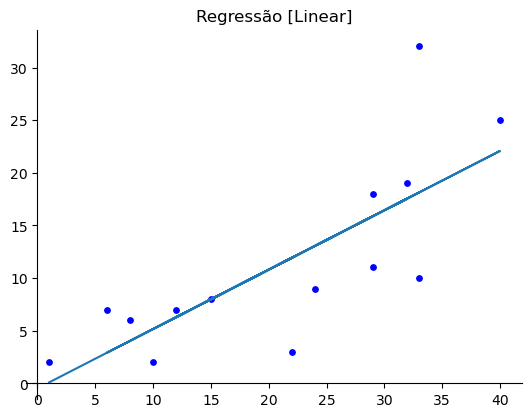

In [24]:
#Exemplo da sorveteria

#Regressão linear de numero dw clientes em relação a temperatura

x = [[22], [10], [33], [40], [15], [8], [6], [29], [32], [12], [24], [29], [33], [1]]; #temperaturas
y = [3, 2, 10, 25, 8, 6, 7, 18, 19, 7, 9, 11, 32, 2]; #Out: número de clientes esperados
fig,ax = plt.subplots()

regressor.fit(x,y);
pred = regressor.predict(x);
ax.scatter(x,y, color='Blue', s=15, label='Data points');
ax.plot(x, pred)

ax.set_title('Regressão [Linear]');
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')



In [25]:
print(regressor.coef_);
print(regressor.intercept_)

[0.56391753]
-0.485125184094251


In [26]:
x2 = [[39], [3], [18]];
regressor.predict(x2).astype(int)

array([21,  1,  9])

*INPUT MULTIDIMENCIONAL*

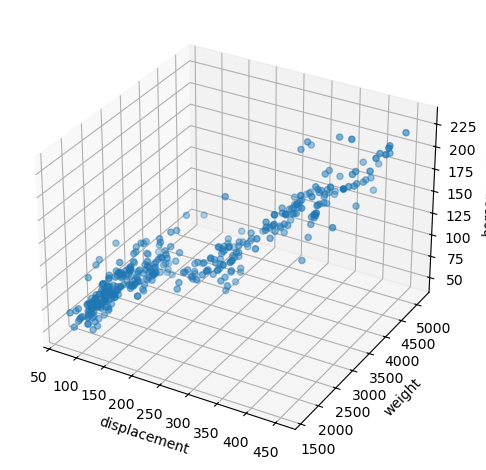

In [27]:
import seaborn as sns
fig = plt.figure(layout='tight');
ax = fig.add_subplot(projection='3d');
mpg = sns.load_dataset('mpg').dropna();

ax.set_xlabel('displacement');
ax.set_ylabel('weight');
ax.set_zlabel('horsepower');
ax.scatter(mpg['displacement'], mpg['weight'], mpg['horsepower'])


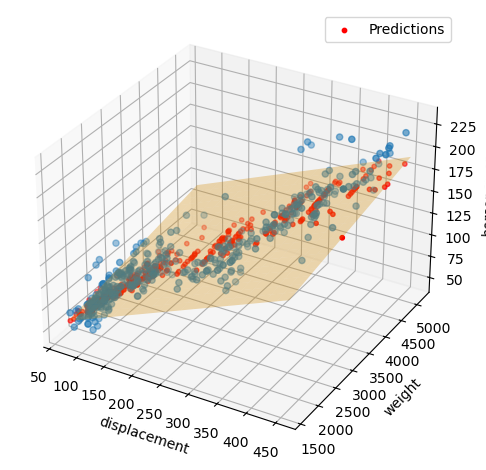

In [28]:
x = np.array(mpg[['displacement', 'weight']]);
y = np.array(mpg['horsepower']);

regressor.fit(x, y);

pred = regressor.predict(x);
fig = plt.figure(layout='tight');
ax = fig.add_subplot(projection='3d');

ax.set_xlabel('displacement');
ax.set_ylabel('weight');
ax.set_zlabel('horsepower');
ax.scatter(mpg['displacement'], mpg['weight'], mpg['horsepower'])
ax.scatter(x[:, 0], x[:, 1], pred, color='red', s=10, label='Predictions')
d_range = np.linspace(mpg['displacement'].min(), mpg['displacement'].max(), 20)
w_range = np.linspace(mpg['weight'].min(), mpg['weight'].max(), 20)
D, W = np.meshgrid(d_range, w_range)
Z = regressor.predict(np.c_[D.ravel(), W.ravel()]).reshape(D.shape)
ax.plot_surface(D, W, Z, color='orange', alpha=0.3)

ax.legend()

In [29]:
regressor.predict([[236, 3600]])

array([121.14267242])

*Verificando a acuracia do modelo de regressão linear*

O modelo verifica a acuracia refazendo o predict novamente do dataset e comparando com o dataset original

In [30]:
regressor.score(mpg[['displacement', 'weight']],mpg['horsepower'])

/home/guihigino/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


0.8108673781277234

**Classificação Linear**

O dataset de entrada é uma lista de vetores e o de saída uma lista de categorias

Exemplo de elementos da lista de entrada e de saída para piguins

x = [peso, grossura do bico]; #In
y = macho ou fêmeia  #Out


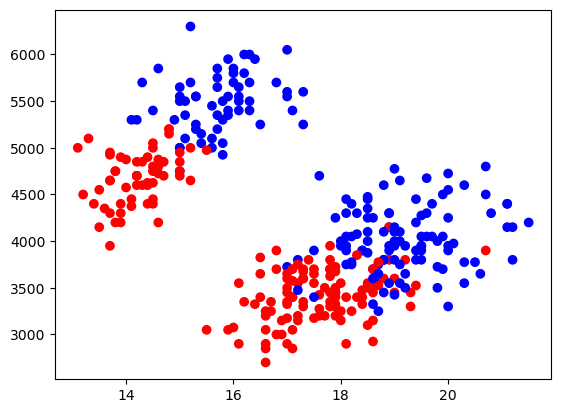

In [39]:
penguins = sns.load_dataset('penguins').dropna()
from sklearn import svm
classificator = svm.LinearSVC();

cores = ['red' if s == 'Female' else 'blue' for s in penguins['sex']];
plt.scatter(penguins['bill_depth_mm'], penguins['body_mass_g'], c=cores);




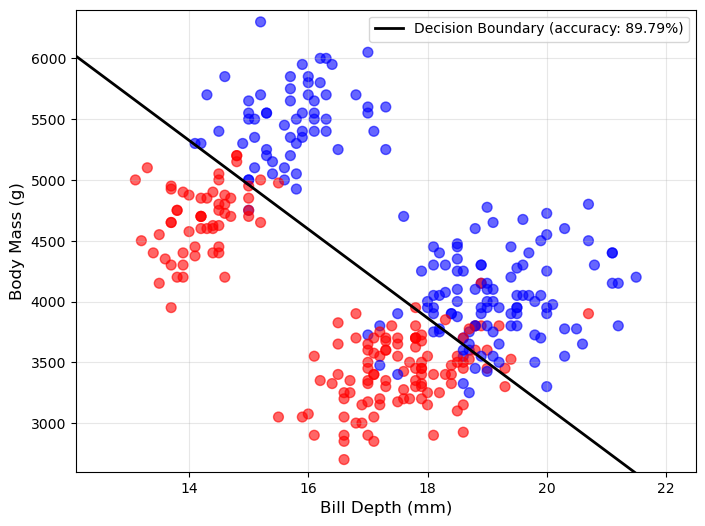

In [ ]:
classificator.fit(penguins[['body_mass_g', 'bill_depth_mm']], penguins['sex'])

fig, ax = plt.subplots(figsize=(8, 6))

cores = ['red' if s == 'Female' else 'blue' for s in penguins['sex']];
ax.scatter(penguins['bill_depth_mm'], penguins['body_mass_g'], c=cores, s=50, alpha=0.6);
taxa = classificator.score(penguins[['body_mass_g', 'bill_depth_mm']], penguins['sex']);
w = classificator.coef_
b_inter = classificator.intercept_

# Create a mesh to plot decision boundary
xmin, xmax = penguins['bill_depth_mm'].min() - 1, penguins['bill_depth_mm'].max() + 1
ymin, ymax = penguins['body_mass_g'].min() - 100, penguins['body_mass_g'].max() + 100

xx = np.linspace(xmin, xmax, 100)
yy = -(w[0][1] * xx + b_inter[0]) / w[0][0]

ax.plot(xx, yy, c='black', linewidth=2, label=f'Decision Boundary (accuracy: {round(100*taxa, 2)}%)')
ax.set_xlabel('Bill Depth (mm)', fontsize=12)
ax.set_ylabel('Body Mass (g)', fontsize=12)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)


In [33]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [38]:
x = [[3450, 19.13]]
print(classificator.predict(x))

['Female']


/home/guihigino/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
